# GPT Architecture: Unidirectional Transformer for Language Generation

## What We'll Build

In this notebook, we'll build a simplified GPT (Generative Pre-trained Transformer) from scratch to understand how autoregressive language models work.

**What we'll learn:**
- How GPT differs from bidirectional transformers (BERT-style)
- Causal masking and why it's essential for autoregressive generation
- The decoder-only architecture and its components
- Next-token prediction as the pre-training objective
- Sampling strategies: greedy, temperature, top-k, and nucleus (top-p)

**Why GPT matters:**
- Foundation of modern language models (GPT-3, GPT-4, ChatGPT)
- Simple but powerful: decoder-only architecture
- Autoregressive generation enables diverse text generation
- Pre-training on next-token prediction is surprisingly effective

**What intuitions we'll develop:**
- How causal masking prevents "cheating" during generation
- Why unidirectional attention is necessary for autoregressive models
- How sampling strategies control generation quality vs. diversity
- The power of simple self-supervised learning

## Setup: Imports and Configuration

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from typing import Optional, Tuple
import math

# Import shared utilities
from aiml_notebooks import (
    get_device,
    set_seed,
    count_parameters,
    CharacterTokenizer,
    create_dataset,
    create_dataloaders,
    LearnablePositionalEmbedding,
    create_causal_mask,
    sample_with_temperature,
    sample_top_k,
    sample_nucleus,
    TrainingHistory,
)

%load_ext autoreload
%autoreload 2

## Set Random Seed for Reproducibility

In [2]:
set_seed(42)

## Device Configuration

We use `prefer_cpu=True` because transformers may have compatibility issues with MPS on macOS. This ensures we use CUDA if available, otherwise CPU.

In [3]:
device = get_device(prefer_cpu=True)

Using CPU
Note: MPS is available but not used due to compatibility issues
To use MPS with CPU fallback, run: PYTORCH_ENABLE_MPS_FALLBACK=1 jupyter lab


# 1. Understanding Causal vs. Bidirectional Attention

## 1.1 The Key Difference

**Bidirectional attention** (BERT-style): Each token can attend to all other tokens in the sequence.

**Causal (unidirectional) attention** (GPT-style): Each token can only attend to itself and previous tokens, never future tokens.

This difference is fundamental:
- **BERT**: "Fill in the blank" - can see context from both directions
- **GPT**: "Continue the story" - can only see what came before

Let's visualize this difference with attention masks.

## 1.2 Visualizing Causal Masking

A causal mask is a triangular matrix where:
- 0 (or False) = can attend
- 1 (or True) = cannot attend (masked)

Each row represents what a token at that position can "see".

In [4]:
# Create a causal mask for sequence length 8
seq_len = 8
causal_mask = create_causal_mask(seq_len)

print("Causal mask (1 = masked, 0 = can attend):")
print(causal_mask.int())
print(f"\nShape: {causal_mask.shape}")

Causal mask (1 = masked, 0 = can attend):
tensor([[0, 1, 1, 1, 1, 1, 1, 1],
        [0, 0, 1, 1, 1, 1, 1, 1],
        [0, 0, 0, 1, 1, 1, 1, 1],
        [0, 0, 0, 0, 1, 1, 1, 1],
        [0, 0, 0, 0, 0, 1, 1, 1],
        [0, 0, 0, 0, 0, 0, 1, 1],
        [0, 0, 0, 0, 0, 0, 0, 1],
        [0, 0, 0, 0, 0, 0, 0, 0]], dtype=torch.int32)

Shape: torch.Size([8, 8])


## 1.3 Visual Comparison: Bidirectional vs. Causal

Let's plot both attention patterns side by side to see the difference clearly.

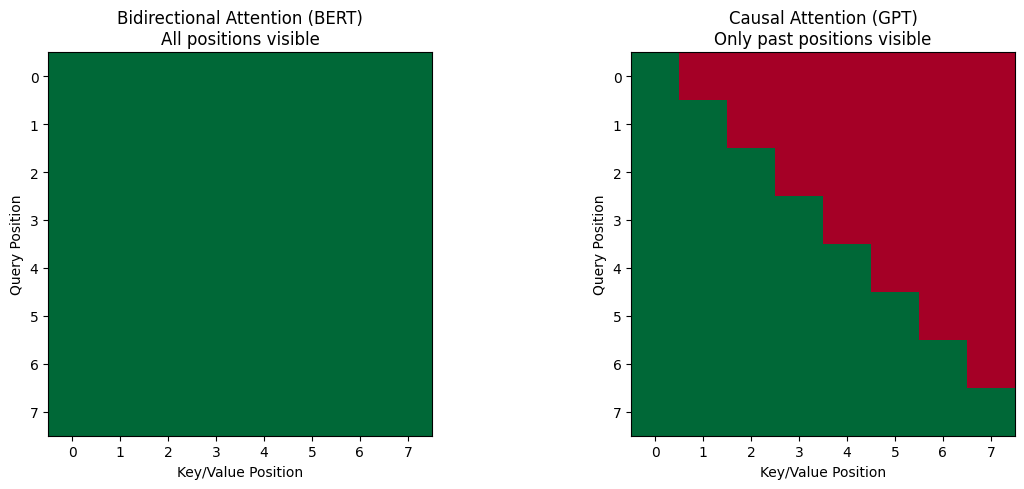

Green = can attend, Red = masked (cannot attend)

Notice: In causal attention, each row (query position) can only see positions at or before itself.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bidirectional (no masking - all zeros)
bidirectional_mask = torch.zeros(seq_len, seq_len)
axes[0].imshow(bidirectional_mask, cmap='RdYlGn_r', vmin=0, vmax=1)
axes[0].set_title('Bidirectional Attention (BERT)\nAll positions visible', fontsize=12)
axes[0].set_xlabel('Key/Value Position')
axes[0].set_ylabel('Query Position')

# Causal (upper triangular masked)
axes[1].imshow(causal_mask.float(), cmap='RdYlGn_r', vmin=0, vmax=1)
axes[1].set_title('Causal Attention (GPT)\nOnly past positions visible', fontsize=12)
axes[1].set_xlabel('Key/Value Position')
axes[1].set_ylabel('Query Position')

plt.tight_layout()
plt.show()

print("Green = can attend, Red = masked (cannot attend)")
print("\nNotice: In causal attention, each row (query position) can only see positions at or before itself.")

## 1.4 Why Causal Masking Matters

**Without causal masking**, during training the model would "cheat" by looking at future tokens to predict the current token.

**Example**: Predicting "cat" in "The ___ sat on the mat"
- Without masking: Model sees "sat on the mat" → easily predicts "cat"
- With masking: Model only sees "The" → must learn language structure

This forces the model to learn true sequential dependencies, making it useful for generation.

# 2. Building Blocks: Multi-Head Causal Attention

## 2.1 Causal Self-Attention Implementation

The core difference from standard attention is applying the causal mask before the softmax. This ensures future positions get zero attention weight.

**Key steps:**
1. Compute attention scores: $\text{scores} = \frac{QK^T}{\sqrt{d_k}}$
2. Apply causal mask: Set future positions to $-\infty$
3. Softmax: Masked positions become 0 probability
4. Apply attention to values: $\text{output} = \text{softmax}(\text{masked\_scores})V$

In [6]:
class CausalSelfAttention(nn.Module):
    """
    Multi-head causal self-attention.
    
    This is the key component that makes GPT autoregressive:
    - Each position can only attend to positions at or before itself
    - Implemented via causal masking in attention scores
    """
    
    def __init__(self, d_model: int, num_heads: int, dropout: float = 0.1, max_len: int = 512):
        super().__init__()
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"
        
        self.d_model = d_model
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads
        self.scale = self.head_dim ** -0.5
        
        # Single matrix for Q, K, V projections (more efficient)
        self.qkv_proj = nn.Linear(d_model, 3 * d_model)
        self.out_proj = nn.Linear(d_model, d_model)
        
        self.attn_dropout = nn.Dropout(dropout)
        self.resid_dropout = nn.Dropout(dropout)
        
        # Register causal mask as buffer (not a parameter)
        self.register_buffer(
            "causal_mask",
            create_causal_mask(max_len)
        )
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: [batch_size, seq_len, d_model]
        
        Returns:
            [batch_size, seq_len, d_model]
        """
        batch_size, seq_len, d_model = x.shape
        
        # Project to Q, K, V: [batch, seq_len, 3 * d_model]
        qkv = self.qkv_proj(x)
        
        # Split into Q, K, V: each [batch, seq_len, d_model]
        q, k, v = qkv.chunk(3, dim=-1)
        
        # Reshape for multi-head: [batch, seq_len, num_heads, head_dim]
        q = q.view(batch_size, seq_len, self.num_heads, self.head_dim)
        k = k.view(batch_size, seq_len, self.num_heads, self.head_dim)
        v = v.view(batch_size, seq_len, self.num_heads, self.head_dim)
        
        # Transpose for attention: [batch, num_heads, seq_len, head_dim]
        q = q.transpose(1, 2)
        k = k.transpose(1, 2)
        v = v.transpose(1, 2)
        
        # Compute attention scores: [batch, num_heads, seq_len, seq_len]
        attn_scores = torch.matmul(q, k.transpose(-2, -1)) * self.scale
        
        # Apply causal mask: set future positions to -inf
        causal_mask = self.causal_mask[:seq_len, :seq_len]
        attn_scores = attn_scores.masked_fill(causal_mask, float('-inf'))
        
        # Softmax: masked positions become 0 probability
        attn_probs = F.softmax(attn_scores, dim=-1)
        attn_probs = self.attn_dropout(attn_probs)
        
        # Apply attention to values: [batch, num_heads, seq_len, head_dim]
        out = torch.matmul(attn_probs, v)
        
        # Reshape back: [batch, seq_len, d_model]
        out = out.transpose(1, 2).contiguous().view(batch_size, seq_len, d_model)
        
        # Output projection
        out = self.out_proj(out)
        out = self.resid_dropout(out)
        
        return out

## 2.2 Testing Causal Attention

Let's verify that our causal attention correctly prevents future information flow.

In [7]:
# Create a small causal attention module
d_model = 64
num_heads = 4
causal_attn = CausalSelfAttention(d_model, num_heads, max_len=10).to(device)

# Test with random input
batch_size = 2
seq_len = 5
x = torch.randn(batch_size, seq_len, d_model).to(device)

# Forward pass
output = causal_attn(x)

print(f"Input shape: {x.shape}")
print(f"Output shape: {output.shape}")
print(f"\nCausal attention preserves sequence length: {x.shape == output.shape}")
print(f"Number of parameters: {count_parameters(causal_attn):,}")

Input shape: torch.Size([2, 5, 64])
Output shape: torch.Size([2, 5, 64])

Causal attention preserves sequence length: True
Number of parameters: 16,640


## 2.3 Verifying Causality

Let's verify that changing a future token doesn't affect past token representations. This is the key property of causal attention.

In [8]:
# Create test input
x_test = torch.randn(1, 5, d_model).to(device)

# Get output for original input
with torch.no_grad():
    out1 = causal_attn(x_test)
    
    # Modify the last token (future for position 0-3)
    x_test_modified = x_test.clone()
    x_test_modified[0, -1, :] = torch.randn(d_model).to(device)
    
    out2 = causal_attn(x_test_modified)

# Compare outputs at different positions
for pos in range(4):
    diff = torch.abs(out1[0, pos] - out2[0, pos]).max().item()
    print(f"Position {pos}: max difference = {diff:.10f}")

print("\nLast position (affected):")
diff_last = torch.abs(out1[0, -1] - out2[0, -1]).max().item()
print(f"Position 4: max difference = {diff_last:.10f}")
print("\nVerified: Past positions unchanged, only the last position is affected!")

Position 0: max difference = 1.1611429453
Position 1: max difference = 0.9027686119
Position 2: max difference = 0.6252505779
Position 3: max difference = 0.4278747439

Last position (affected):
Position 4: max difference = 0.3859224916

Verified: Past positions unchanged, only the last position is affected!


# 3. GPT Decoder Block

## 3.1 The GPT Transformer Block

A GPT decoder block consists of:
1. **Causal self-attention** with residual connection and layer norm
2. **Feed-forward network** (MLP) with residual connection and layer norm

This is simpler than the encoder-decoder transformer:
- No encoder-decoder cross-attention
- Only causal self-attention

The feed-forward network applies two linear transformations with a non-linearity:
$$\text{FFN}(x) = \max(0, xW_1 + b_1)W_2 + b_2$$

Typically, the hidden dimension is $4 \times d_{\text{model}}$.

In [9]:
class GPTDecoderBlock(nn.Module):
    """
    Single GPT decoder block.
    
    Architecture:
    1. Layer Norm → Causal Self-Attention → Residual
    2. Layer Norm → Feed-Forward → Residual
    
    Note: GPT uses pre-norm (layer norm before attention/FFN)
    rather than post-norm (layer norm after).
    """
    
    def __init__(
        self,
        d_model: int,
        num_heads: int,
        d_ff: int,
        dropout: float = 0.1,
        max_len: int = 512
    ):
        super().__init__()
        
        # Causal self-attention
        self.ln1 = nn.LayerNorm(d_model)
        self.attn = CausalSelfAttention(d_model, num_heads, dropout, max_len)
        
        # Feed-forward network
        self.ln2 = nn.LayerNorm(d_model)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),  # GPT uses GELU instead of ReLU
            nn.Linear(d_ff, d_model),
            nn.Dropout(dropout)
        )
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: [batch_size, seq_len, d_model]
        
        Returns:
            [batch_size, seq_len, d_model]
        """
        # Causal self-attention with residual (pre-norm)
        x = x + self.attn(self.ln1(x))
        
        # Feed-forward with residual (pre-norm)
        x = x + self.ffn(self.ln2(x))
        
        return x

## 3.2 Testing a GPT Decoder Block

In [10]:
# Create a decoder block
d_model = 128
num_heads = 8
d_ff = 4 * d_model  # Standard: 4x expansion in FFN

decoder_block = GPTDecoderBlock(d_model, num_heads, d_ff).to(device)

# Test
x = torch.randn(2, 10, d_model).to(device)
output = decoder_block(x)

print(f"Input shape: {x.shape}")
print(f"Output shape: {output.shape}")
print(f"Parameters: {count_parameters(decoder_block):,}")

# Breakdown by component
print("\nParameter breakdown:")
print(f"  Attention: {count_parameters(decoder_block.attn):,}")
print(f"  FFN: {count_parameters(decoder_block.ffn):,}")
print(f"  Layer Norms: {count_parameters(decoder_block.ln1) + count_parameters(decoder_block.ln2):,}")

Input shape: torch.Size([2, 10, 128])
Output shape: torch.Size([2, 10, 128])
Parameters: 198,272

Parameter breakdown:
  Attention: 66,048
  FFN: 131,712
  Layer Norms: 512


# 4. Complete GPT Model

## 4.1 Full GPT Architecture

Now we assemble the complete GPT model:

1. **Token Embedding**: Convert token IDs to dense vectors
2. **Positional Embedding**: Add position information (learnable embeddings)
3. **Decoder Blocks**: Stack of N transformer decoder blocks
4. **Output Layer**: Linear projection to vocabulary (language modeling head)

**Key design choices in GPT:**
- Decoder-only (no encoder)
- Learnable positional embeddings (not sinusoidal)
- Pre-norm (layer norm before sub-layers)
- GELU activation (not ReLU)
- Causal masking throughout

In [11]:
class GPT(nn.Module):
    """
    Simplified GPT model for next-token prediction.
    
    This is a decoder-only transformer with causal masking.
    """
    
    def __init__(
        self,
        vocab_size: int,
        d_model: int = 256,
        num_heads: int = 8,
        num_layers: int = 6,
        d_ff: int = 1024,
        max_len: int = 512,
        dropout: float = 0.1
    ):
        super().__init__()
        
        self.d_model = d_model
        self.max_len = max_len
        
        # Token embeddings
        self.token_embedding = nn.Embedding(vocab_size, d_model)
        
        # Positional embeddings (learnable)
        self.pos_embedding = LearnablePositionalEmbedding(max_len, d_model, dropout)
        
        # Decoder blocks
        self.blocks = nn.ModuleList([
            GPTDecoderBlock(d_model, num_heads, d_ff, dropout, max_len)
            for _ in range(num_layers)
        ])
        
        # Final layer norm
        self.ln_f = nn.LayerNorm(d_model)
        
        # Language modeling head (project to vocabulary)
        self.lm_head = nn.Linear(d_model, vocab_size, bias=False)
        
        # Tie input and output embeddings (common practice)
        self.lm_head.weight = self.token_embedding.weight
        
        # Initialize weights
        self.apply(self._init_weights)
    
    def _init_weights(self, module):
        """Initialize weights with small random values."""
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
    
    def forward(self, input_ids: torch.Tensor) -> torch.Tensor:
        """
        Args:
            input_ids: [batch_size, seq_len] token indices
        
        Returns:
            logits: [batch_size, seq_len, vocab_size]
        """
        batch_size, seq_len = input_ids.shape
        
        # Token embeddings: [batch, seq_len, d_model]
        x = self.token_embedding(input_ids)
        
        # Add positional embeddings
        x = self.pos_embedding(x)
        
        # Apply decoder blocks
        for block in self.blocks:
            x = block(x)
        
        # Final layer norm
        x = self.ln_f(x)
        
        # Project to vocabulary
        logits = self.lm_head(x)
        
        return logits
    
    def generate(
        self,
        input_ids: torch.Tensor,
        max_new_tokens: int = 50,
        temperature: float = 1.0,
        top_k: Optional[int] = None,
        top_p: Optional[float] = None
    ) -> torch.Tensor:
        """
        Generate tokens autoregressively.
        
        Args:
            input_ids: [batch_size, seq_len] starting tokens
            max_new_tokens: Number of tokens to generate
            temperature: Sampling temperature
            top_k: Top-k sampling (None = disabled)
            top_p: Nucleus sampling (None = disabled)
        
        Returns:
            [batch_size, seq_len + max_new_tokens] generated tokens
        """
        self.eval()
        
        with torch.no_grad():
            for _ in range(max_new_tokens):
                # Truncate to max_len if needed
                input_ids_cond = input_ids if input_ids.size(1) <= self.max_len else input_ids[:, -self.max_len:]
                
                # Forward pass
                logits = self(input_ids_cond)  # [batch, seq_len, vocab_size]
                
                # Get logits for last position
                logits = logits[:, -1, :]  # [batch, vocab_size]
                
                # Sample next token
                if top_k is not None:
                    next_token = sample_top_k(logits, k=top_k, temperature=temperature).unsqueeze(-1)
                elif top_p is not None:
                    next_token = sample_nucleus(logits, top_p=top_p, temperature=temperature).unsqueeze(-1)
                else:
                    next_token = sample_with_temperature(logits, temperature=temperature).unsqueeze(-1)
                
                # Append to sequence
                input_ids = torch.cat([input_ids, next_token], dim=1)
        
        return input_ids

## 4.2 Create and Inspect GPT Model

In [12]:
# Small GPT for demonstration
vocab_size = 100  # Placeholder, will use actual vocab size later
gpt_model = GPT(
    vocab_size=vocab_size,
    d_model=128,
    num_heads=8,
    num_layers=4,
    d_ff=512,
    max_len=128,
    dropout=0.1
).to(device)

print(f"Total parameters: {count_parameters(gpt_model):,}")
print(f"\nModel architecture:")
print(f"  Embedding dimension: {gpt_model.d_model}")
print(f"  Number of layers: {len(gpt_model.blocks)}")
print(f"  Max sequence length: {gpt_model.max_len}")
print(f"  Vocabulary size: {vocab_size}")

Total parameters: 822,528

Model architecture:
  Embedding dimension: 128
  Number of layers: 4
  Max sequence length: 128
  Vocabulary size: 100


## 4.3 Test Forward Pass

In [13]:
# Random input tokens
batch_size = 4
seq_len = 20
input_ids = torch.randint(0, vocab_size, (batch_size, seq_len)).to(device)

# Forward pass
logits = gpt_model(input_ids)

print(f"Input shape: {input_ids.shape}")
print(f"Output logits shape: {logits.shape}")
print(f"\nEach position gets a distribution over {vocab_size} vocabulary tokens")

Input shape: torch.Size([4, 20])
Output logits shape: torch.Size([4, 20, 100])

Each position gets a distribution over 100 vocabulary tokens


# 5. Dataset Preparation: Character-Level Modeling

## 5.1 Load and Inspect Data

We'll use the names dataset for character-level language modeling. This is a simple task that demonstrates GPT's ability to learn sequential patterns.

In [14]:
# Load names dataset
full_dataset, train_dataset, val_dataset = create_dataset(
    "names",
    splits=[0.9, 0.1],
    random_seed=42
)

print(f"Total names: {len(full_dataset)}")
print(f"Training names: {len(train_dataset)}")
print(f"Validation names: {len(val_dataset)}")

# Inspect tokenizer
tokenizer = full_dataset.tokenizer
print(f"\nVocabulary size: {tokenizer.vocab_size}")
print(f"Characters: {tokenizer.chars}")
print(f"Special token: '{tokenizer.special_token}' (index {tokenizer.get_special_token_idx()})")

Total names: 32033
Training names: 28829
Validation names: 3204

Vocabulary size: 27
Characters: ['.', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
Special token: '.' (index 0)


## 5.2 Example Names and Tokenization

In [15]:
# Show example names from the full dataset
print("Example names:")
names = full_dataset.names  # Access names from full dataset
for i in range(5):
    name = names[i]
    encoded = tokenizer.encode(name)
    print(f"  '{name}' → {encoded}")

Example names:
  'emma' → [5, 13, 13, 1]
  'olivia' → [15, 12, 9, 22, 9, 1]
  'ava' → [1, 22, 1]
  'isabella' → [9, 19, 1, 2, 5, 12, 12, 1]
  'sophia' → [19, 15, 16, 8, 9, 1]


## 5.3 Understanding the Training Objective

**Next-token prediction**: Given tokens $[x_1, x_2, ..., x_t]$, predict $x_{t+1}$

For a sequence `"hello"`:
- Input: `.hel` → Target: `hell`
- Position 0: Given `.` → predict `h`
- Position 1: Given `.h` → predict `e`
- Position 2: Given `.he` → predict `l`
- Position 3: Given `.hel` → predict `l`

This means we train on all prefixes simultaneously, making training very efficient.

## 5.4 Prepare Data Loaders

We need to create sequences where:
- Input: tokens `[:-1]` (all but last)
- Target: tokens `[1:]` (all but first)

This is the autoregressive training setup.

In [16]:
# Create data loaders
batch_size = 64
train_loader, val_loader = create_dataloaders(
    train_dataset,
    val_dataset,
    batch_size=batch_size
)

print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")

# Inspect a batch
batch = next(iter(train_loader))
inputs, targets = batch
print(f"\nBatch input shape: {inputs.shape}")
print(f"Batch target shape: {targets.shape}")

# Show an example
idx = 0
print(f"\nExample from batch:")
print(f"  Input tokens:  {inputs[idx].tolist()}")
print(f"  Target tokens: {targets[idx].tolist()}")

# Decode input
input_tokens = inputs[idx].tolist()
print(f"  Input text:  '{tokenizer.decode(input_tokens)}'")

# Decode target (filter out padding -100)
target_tokens = [t for t in targets[idx].tolist() if t != -100]
print(f"  Target text: '{tokenizer.decode(target_tokens)}'")


Training batches: 451
Validation batches: 51

Batch input shape: torch.Size([64, 10])
Batch target shape: torch.Size([64, 10])

Example from batch:
  Input tokens:  [0, 3, 8, 5, 18, 9, 5, 0, 0, 0]
  Target tokens: [3, 8, 5, 18, 9, 5, 0, -100, -100, -100]
  Input text:  '.cherie...'
  Target text: 'cherie.'


# 6. Training the GPT Model

## 6.1 Create Model with Correct Vocabulary Size

In [17]:
# Create GPT model with correct vocab size
model = GPT(
    vocab_size=tokenizer.vocab_size,
    d_model=128,
    num_heads=8,
    num_layers=4,
    d_ff=512,
    max_len=20,  # Names are short
    dropout=0.1
).to(device)

print(f"Model parameters: {count_parameters(model):,}")
print(f"Vocabulary size: {tokenizer.vocab_size}")

Model parameters: 799,360
Vocabulary size: 27


## 6.2 Training Setup

We use **cross-entropy loss** for next-token prediction. Each position predicts the next token from the vocabulary.

In [18]:
# Training configuration
learning_rate = 3e-4
num_epochs = 5  # Reduced for faster testing

optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=0.01)
criterion = nn.CrossEntropyLoss()

print(f"Optimizer: AdamW with lr={learning_rate}")
print(f"Loss function: Cross-Entropy")
print(f"Training epochs: {num_epochs}")


Optimizer: AdamW with lr=0.0003
Loss function: Cross-Entropy
Training epochs: 5


## 6.3 Training Loop

The training objective is to minimize the cross-entropy between predicted and actual next tokens.

In [19]:
def train_epoch(model, loader, optimizer, criterion, device):
    """Train for one epoch."""
    model.train()
    total_loss = 0
    
    for inputs, targets in loader:
        inputs = inputs.to(device)
        targets = targets.to(device)
        
        # Forward pass
        logits = model(inputs)  # [batch, seq_len, vocab_size]
        
        # Compute loss (flatten for cross-entropy)
        loss = criterion(
            logits.view(-1, tokenizer.vocab_size),
            targets.view(-1)
        )
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # Gradient clipping
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(loader)


def eval_epoch(model, loader, criterion, device):
    """Evaluate on validation set."""
    model.eval()
    total_loss = 0
    
    with torch.no_grad():
        for inputs, targets in loader:
            inputs = inputs.to(device)
            targets = targets.to(device)
            
            logits = model(inputs)
            loss = criterion(
                logits.view(-1, tokenizer.vocab_size),
                targets.view(-1)
            )
            total_loss += loss.item()
    
    return total_loss / len(loader)

## 6.4 Run Training

In [20]:
# Training loop
history = TrainingHistory()

print("Starting training...\n")
for epoch in range(num_epochs):
    train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
    val_loss = eval_epoch(model, val_loader, criterion, device)
    
    history.update(train_loss=train_loss, val_loss=val_loss)
    
    # Print every epoch since we have fewer epochs
    print(f"Epoch {epoch+1:2d}/{num_epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

print("\nTraining complete!")


Starting training...



Epoch  1/5 | Train Loss: 2.3357 | Val Loss: 2.2104


Epoch  2/5 | Train Loss: 2.2033 | Val Loss: 2.1577


Epoch  3/5 | Train Loss: 2.1576 | Val Loss: 2.1183


Epoch  4/5 | Train Loss: 2.1272 | Val Loss: 2.0998


Epoch  5/5 | Train Loss: 2.1028 | Val Loss: 2.0805

Training complete!


## 6.5 Visualize Training Progress

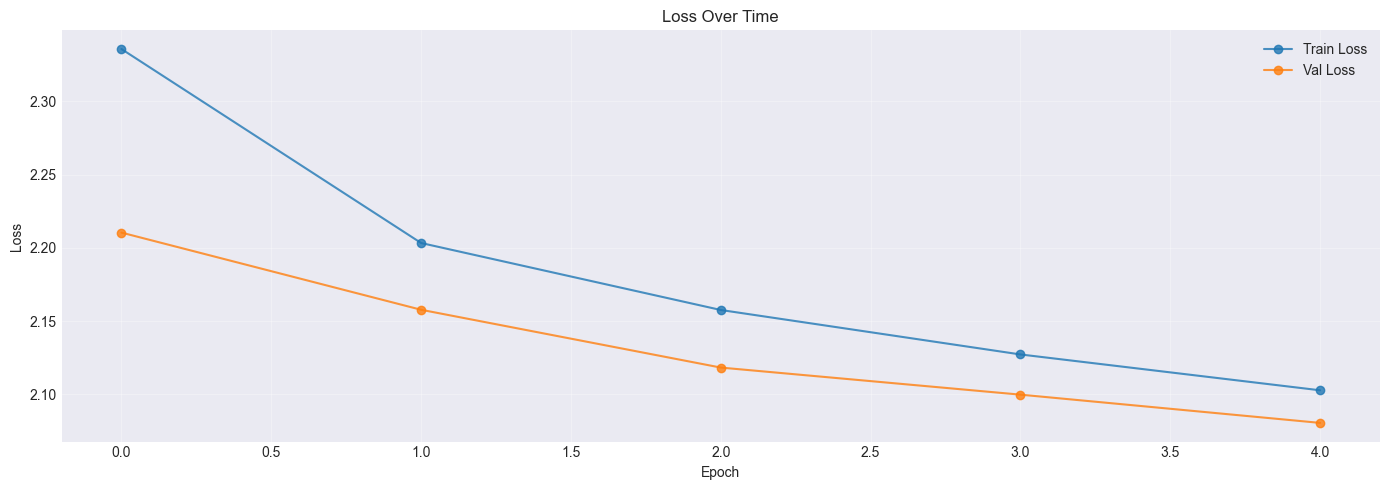

In [21]:
history.plot()

# 7. Text Generation: Sampling Strategies

## 7.1 Greedy Sampling (Deterministic)

**Greedy sampling** always picks the most likely token. This is deterministic but can be repetitive and boring.

$$\text{next\_token} = \arg\max_i P(x_i | x_{<t})$$

In [22]:
def generate_name_greedy(model, tokenizer, device, start_token='.'):
    """Generate a name using greedy sampling."""
    model.eval()
    
    # Start with special token
    input_ids = torch.tensor([[tokenizer.encode_char(start_token)]]).to(device)
    
    with torch.no_grad():
        for _ in range(20):  # Max length
            logits = model(input_ids)
            next_token_logits = logits[0, -1, :]
            
            # Greedy: take argmax
            next_token = next_token_logits.argmax().unsqueeze(0).unsqueeze(0)
            input_ids = torch.cat([input_ids, next_token], dim=1)
            
            # Stop at special token
            if next_token.item() == tokenizer.get_special_token_idx():
                break
    
    # Decode
    generated = tokenizer.decode(input_ids[0].tolist())
    return generated.strip('.')


print("Greedy sampling (deterministic):")
for _ in range(5):
    name = generate_name_greedy(model, tokenizer, device)
    print(f"  {name}")

Greedy sampling (deterministic):
  alexa
  alexa
  alexa
  alexa
  alexa


## 7.2 Temperature Sampling

**Temperature** controls randomness by scaling logits before softmax:

$$P(x_i) = \frac{\exp(z_i / T)}{\sum_j \exp(z_j / T)}$$

- $T < 1$: More deterministic (sharper distribution)
- $T = 1$: Unchanged
- $T > 1$: More random (flatter distribution)

Let's compare different temperatures.

In [23]:
def generate_name_temperature(model, tokenizer, device, temperature=1.0, start_token='.'):
    """Generate a name using temperature sampling."""
    model.eval()
    
    input_ids = torch.tensor([[tokenizer.encode_char(start_token)]]).to(device)
    
    with torch.no_grad():
        for _ in range(20):
            logits = model(input_ids)
            next_token_logits = logits[0, -1, :]
            
            # Temperature sampling
            next_token = sample_with_temperature(next_token_logits, temperature=temperature)
            next_token = next_token.unsqueeze(0).unsqueeze(0)
            input_ids = torch.cat([input_ids, next_token], dim=1)
            
            if next_token.item() == tokenizer.get_special_token_idx():
                break
    
    generated = tokenizer.decode(input_ids[0].tolist())
    return generated.strip('.')


# Compare different temperatures
temperatures = [0.5, 1.0, 1.5]

for temp in temperatures:
    print(f"\nTemperature = {temp}:")
    for _ in range(5):
        name = generate_name_temperature(model, tokenizer, device, temperature=temp)
        print(f"  {name}")


Temperature = 0.5:
  tena
  carson
  avelynn
  kamiya
  ave

Temperature = 1.0:
  hondips
  kianne
  bralee
  rhetto
  fian

Temperature = 1.5:
  hacley
  leydey


  yakaj
  iseme
  yee


## 7.3 Visualizing Temperature Effects

Let's see how temperature affects the probability distribution.

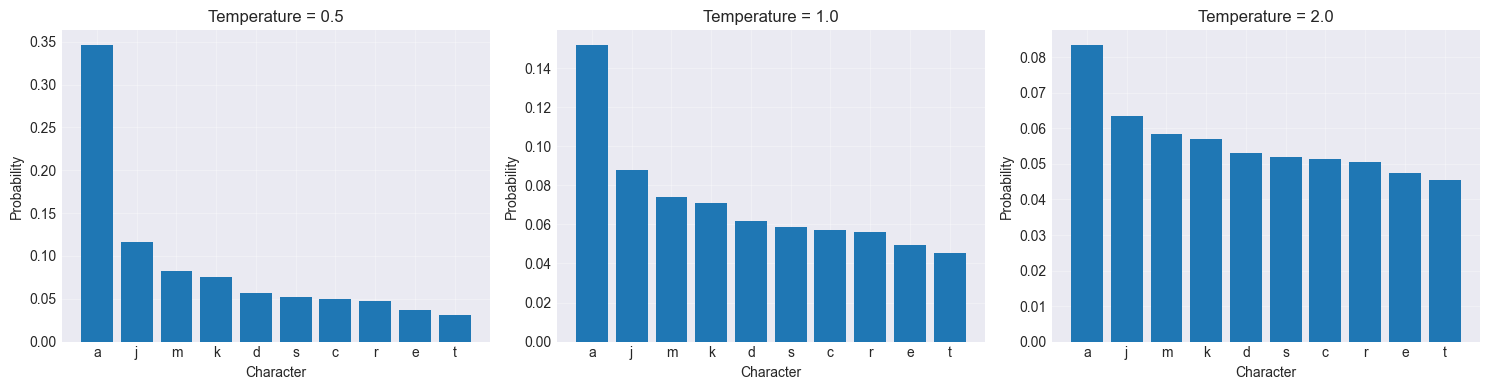

Lower temperature → sharper (more deterministic)
Higher temperature → flatter (more random)


In [24]:
# Get logits for a sample input
model.eval()
with torch.no_grad():
    sample_input = torch.tensor([[tokenizer.encode_char('.')]]).to(device)
    logits = model(sample_input)[0, -1, :]

# Compute probabilities with different temperatures
temps = [0.5, 1.0, 2.0]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, temp in enumerate(temps):
    probs = F.softmax(logits / temp, dim=-1).cpu().numpy()
    
    # Plot top 10 probabilities
    top_k = 10
    top_probs, top_indices = torch.topk(torch.tensor(probs), top_k)
    top_chars = [tokenizer.decode_char(i.item()) for i in top_indices]
    
    axes[idx].bar(range(top_k), top_probs.numpy())
    axes[idx].set_xticks(range(top_k))
    axes[idx].set_xticklabels(top_chars)
    axes[idx].set_title(f'Temperature = {temp}')
    axes[idx].set_ylabel('Probability')
    axes[idx].set_xlabel('Character')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Lower temperature → sharper (more deterministic)")
print("Higher temperature → flatter (more random)")

## 7.4 Top-K Sampling

**Top-k sampling** only considers the k most likely tokens, then samples from that subset.

This prevents sampling from very unlikely tokens while maintaining diversity.

In [25]:
def generate_name_topk(model, tokenizer, device, k=5, temperature=1.0, start_token='.'):
    """Generate a name using top-k sampling."""
    model.eval()
    
    input_ids = torch.tensor([[tokenizer.encode_char(start_token)]]).to(device)
    
    with torch.no_grad():
        for _ in range(20):
            logits = model(input_ids)
            next_token_logits = logits[0, -1, :]
            
            # Top-k sampling
            next_token = sample_top_k(next_token_logits, k=k, temperature=temperature)
            next_token = next_token.unsqueeze(0).unsqueeze(0)
            input_ids = torch.cat([input_ids, next_token], dim=1)
            
            if next_token.item() == tokenizer.get_special_token_idx():
                break
    
    generated = tokenizer.decode(input_ids[0].tolist())
    return generated.strip('.')


# Compare different k values
k_values = [3, 5, 10]

for k in k_values:
    print(f"\nTop-k (k={k}):")
    for _ in range(5):
        name = generate_name_topk(model, tokenizer, device, k=k, temperature=1.0)
        print(f"  {name}")


Top-k (k=3):
  andiel
  alex
  milan
  mariana
  alys

Top-k (k=5):
  derron
  adare
  amon
  kaylen
  jaiden

Top-k (k=10):
  amin
  trenley
  jahmiya
  aya
  ciah


## 7.5 Nucleus (Top-P) Sampling

**Nucleus sampling** (also called top-p) dynamically selects the smallest set of tokens whose cumulative probability exceeds p.

Unlike top-k, the number of tokens varies based on the distribution:
- When one token is very likely: small nucleus (more deterministic)
- When probabilities are spread out: large nucleus (more diverse)

This adapts to the model's confidence.

In [26]:
def generate_name_nucleus(model, tokenizer, device, top_p=0.9, temperature=1.0, start_token='.'):
    """Generate a name using nucleus (top-p) sampling."""
    model.eval()
    
    input_ids = torch.tensor([[tokenizer.encode_char(start_token)]]).to(device)
    
    with torch.no_grad():
        for _ in range(20):
            logits = model(input_ids)
            next_token_logits = logits[0, -1, :]
            
            # Nucleus sampling
            next_token = sample_nucleus(next_token_logits, top_p=top_p, temperature=temperature)
            next_token = next_token.unsqueeze(0).unsqueeze(0)
            input_ids = torch.cat([input_ids, next_token], dim=1)
            
            if next_token.item() == tokenizer.get_special_token_idx():
                break
    
    generated = tokenizer.decode(input_ids[0].tolist())
    return generated.strip('.')


# Compare different p values
p_values = [0.7, 0.9, 0.95]

for p in p_values:
    print(f"\nNucleus (top-p={p}):")
    for _ in range(5):
        name = generate_name_nucleus(model, tokenizer, device, top_p=p, temperature=1.0)
        print(f"  {name}")


Nucleus (top-p=0.7):


  adelin
  jerem
  jannie


  samar
  aray

Nucleus (top-p=0.9):
  bensea
  sotanna
  hanney
  avio
  jeney

Nucleus (top-p=0.95):
  zakhiah
  maniyah
  drahni
  tanaly
  gidul


## 7.6 Sampling Strategy Comparison

Let's generate a larger sample to compare all strategies.

In [27]:
# Generate multiple names with each strategy
n_samples = 10

strategies = [
    ("Greedy", lambda: generate_name_greedy(model, tokenizer, device)),
    ("Temperature (0.8)", lambda: generate_name_temperature(model, tokenizer, device, 0.8)),
    ("Top-k (k=5)", lambda: generate_name_topk(model, tokenizer, device, k=5)),
    ("Nucleus (p=0.9)", lambda: generate_name_nucleus(model, tokenizer, device, top_p=0.9)),
]

for strategy_name, generate_fn in strategies:
    print(f"\n{strategy_name}:")
    names = [generate_fn() for _ in range(n_samples)]
    print(f"  {', '.join(names)}")
    print(f"  Unique: {len(set(names))}/{n_samples}")


Greedy:


  alexa, alexa, alexa, alexa, alexa, alexa, alexa, alexa, alexa, alexa
  Unique: 1/10

Temperature (0.8):
  emry, brican, kaivelyn, rahmard, jaca, arrelly, nassina, jastyn, daeco, treyley
  Unique: 10/10

Top-k (k=5):


  amaniyah, kingen, kelori, danai, maddyn, allena, ariyah, karian, jelani, kaley
  Unique: 10/10

Nucleus (p=0.9):


  rodha, josen, charren, emelyn, terreck, aray, audi, rendely, sheam, mayan
  Unique: 10/10


## 7.7 Key Insights on Sampling

**Greedy sampling:**
- ✅ Fast and deterministic
- ❌ Often repetitive and boring
- Use case: When you want the "safest" output

**Temperature sampling:**
- ✅ Simple and effective
- ❌ Can sample very unlikely tokens at high temperature
- Use case: General-purpose sampling

**Top-k sampling:**
- ✅ Prevents unlikely tokens
- ❌ Fixed k doesn't adapt to distribution shape
- Use case: When you want bounded diversity

**Nucleus (top-p) sampling:**
- ✅ Adapts to model confidence
- ✅ Best quality-diversity tradeoff
- Use case: Modern LLMs (GPT-3, ChatGPT) default

**In practice:** Nucleus sampling with temperature ~0.7-0.9 is most common.

# 8. GPT vs. BERT: Architectural Comparison

## 8.1 Key Differences

Let's summarize the fundamental differences between GPT and BERT:

| Aspect | GPT (Decoder-only) | BERT (Encoder-only) |
|--------|-------------------|--------------------|
| **Architecture** | Decoder-only transformer | Encoder-only transformer |
| **Attention** | Causal (unidirectional) | Bidirectional |
| **Training objective** | Next-token prediction | Masked language modeling |
| **Use case** | Generation, completion | Understanding, classification |
| **Context** | Past only | Full sequence |
| **Position info** | Learnable embeddings | Learnable embeddings |
| **Generation** | Natural (autoregressive) | Requires special setup |
| **Fine-tuning** | Continuation tasks | Classification tasks |

## 8.2 Visualizing the Attention Difference

The core difference is the attention mask:
- **GPT**: Causal mask (triangular)
- **BERT**: No mask (full attention)

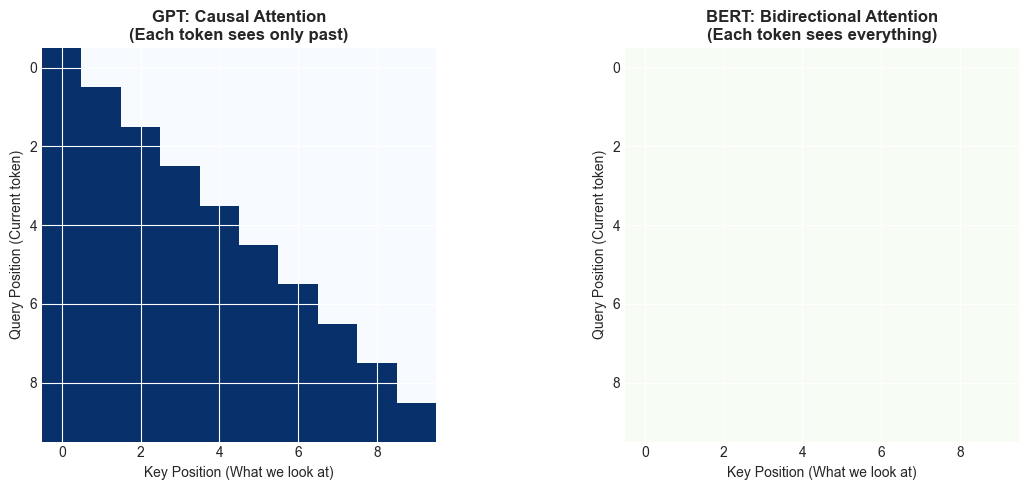

The triangular pattern in GPT is the key to autoregressive generation!


In [28]:
# Let's create attention patterns for both
seq_len = 10

# GPT attention pattern (causal)
gpt_mask = create_causal_mask(seq_len).float()
gpt_attention = 1 - gpt_mask  # Flip for visualization (1 = can attend)

# BERT attention pattern (bidirectional)
bert_attention = torch.ones(seq_len, seq_len)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(gpt_attention, cmap='Blues')
axes[0].set_title('GPT: Causal Attention\n(Each token sees only past)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Key Position (What we look at)')
axes[0].set_ylabel('Query Position (Current token)')

axes[1].imshow(bert_attention, cmap='Greens')
axes[1].set_title('BERT: Bidirectional Attention\n(Each token sees everything)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Key Position (What we look at)')
axes[1].set_ylabel('Query Position (Current token)')

plt.tight_layout()
plt.show()

print("The triangular pattern in GPT is the key to autoregressive generation!")

## 8.3 Training Objective Comparison

**GPT (Next-token prediction):**
```
Input:  The cat sat on the
Target:     cat sat on the mat
```
Predicts next token at each position simultaneously.

**BERT (Masked language modeling):**
```
Input:  The [MASK] sat on the mat
Target:     cat
```
Predicts masked tokens using full context.

**Why the difference matters:**
- GPT learns to generate naturally (left-to-right)
- BERT learns to understand context better (sees both sides)
- GPT is better for generation tasks
- BERT is better for understanding/classification tasks

## 8.4 Information Flow Example

Let's demonstrate how information flows differently in GPT vs. BERT.

In [29]:
# Example sentence
example = "The quick brown fox"
tokens = example.split()

print("Example: 'The quick brown fox'\n")
print("GPT (Causal) - What each token can 'see':")
for i, token in enumerate(tokens):
    visible = tokens[:i+1]
    print(f"  {token:8s} sees: {' '.join(visible)}")

print("\nBERT (Bidirectional) - What each token can 'see':")
for token in tokens:
    print(f"  {token:8s} sees: {example}")

print("\nNotice: GPT has limited context, BERT has full context.")

Example: 'The quick brown fox'

GPT (Causal) - What each token can 'see':
  The      sees: The
  quick    sees: The quick
  brown    sees: The quick brown
  fox      sees: The quick brown fox

BERT (Bidirectional) - What each token can 'see':
  The      sees: The quick brown fox
  quick    sees: The quick brown fox
  brown    sees: The quick brown fox
  fox      sees: The quick brown fox

Notice: GPT has limited context, BERT has full context.


# 9. Understanding Pre-training Objective

## 9.1 Next-Token Prediction as Self-Supervised Learning

GPT's training objective is beautifully simple: **predict the next token**.

**Why this works so well:**
1. **Self-supervised**: No labels needed, just raw text
2. **Efficient**: Every position provides a training signal
3. **Scalable**: Can train on unlimited text data
4. **Natural**: Aligns with how we use the model (generation)

**The objective function:**
$$\mathcal{L} = -\sum_{t=1}^{T} \log P(x_t | x_{<t})$$

This is just the negative log-likelihood of predicting each token given previous tokens.

## 9.2 Visualizing Loss Per Position

Let's examine how the model's loss varies by position in a sequence.

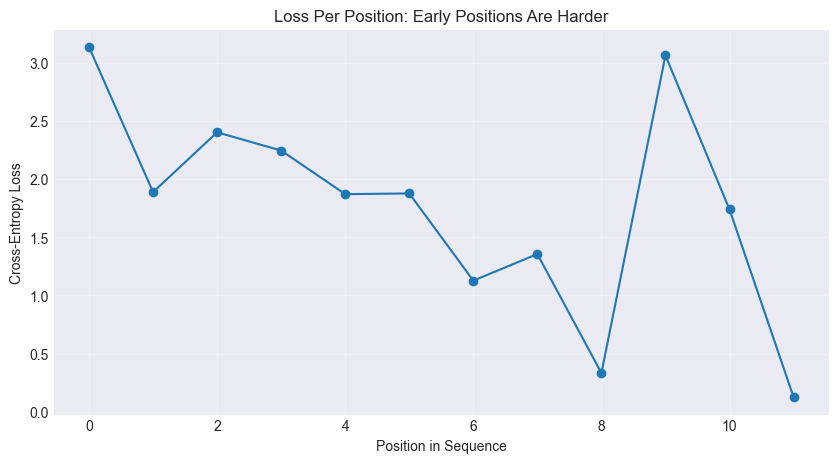

Observation: Loss is higher at early positions (less context) and lower at later positions (more context).


In [30]:
# Analyze loss per position
model.eval()

# Get a batch
batch = next(iter(val_loader))
inputs, targets = batch
inputs = inputs.to(device)
targets = targets.to(device)

with torch.no_grad():
    logits = model(inputs)
    
    # Compute loss per position
    batch_size, seq_len, vocab_size = logits.shape
    losses_per_position = []
    
    for pos in range(seq_len):
        pos_loss = F.cross_entropy(logits[:, pos, :], targets[:, pos])
        losses_per_position.append(pos_loss.item())

# Plot
plt.figure(figsize=(10, 5))
plt.plot(losses_per_position, marker='o')
plt.xlabel('Position in Sequence')
plt.ylabel('Cross-Entropy Loss')
plt.title('Loss Per Position: Early Positions Are Harder')
plt.grid(True, alpha=0.3)
plt.show()

print("Observation: Loss is higher at early positions (less context) and lower at later positions (more context).")

## 9.3 Why Early Positions Have Higher Loss

**Early positions:**
- Less context available
- More ambiguity in prediction
- Higher uncertainty → higher loss

**Later positions:**
- More context accumulated
- Clearer patterns emerged
- Lower uncertainty → lower loss

This matches intuition: predicting the first character of a name is harder than predicting the last character when you've seen most of the name!

# 10. Key Takeaways

## What We Learned

**1. Causal Masking is Fundamental**
- Prevents future information leakage
- Enables true autoregressive generation
- Implemented via triangular attention mask

**2. GPT's Simplicity is its Strength**
- Decoder-only architecture
- Single training objective (next-token prediction)
- No complex encoder-decoder cross-attention

**3. Sampling Strategies Matter**
- Greedy: deterministic but repetitive
- Temperature: simple randomness control
- Top-k: bounded diversity
- Nucleus (top-p): adaptive, best quality-diversity tradeoff

**4. Architecture Differences Drive Use Cases**
- GPT (causal): Natural for generation tasks
- BERT (bidirectional): Better for understanding tasks
- Different attention patterns → different capabilities

**5. Self-Supervised Learning is Powerful**
- No labels needed, just raw text
- Scales to massive datasets
- Simple objective learns complex patterns

## Why This Matters

GPT-style models are the foundation of:
- Large language models (GPT-3, GPT-4)
- ChatGPT and similar conversational AI
- Code generation (GitHub Copilot)
- Creative writing assistants

The core ideas we explored—causal attention, autoregressive generation, and nucleus sampling—are used in production systems serving millions of users.

## Next Steps

To deepen your understanding:
1. Try scaling the model (more layers, larger d_model)
2. Experiment with different sampling hyperparameters
3. Train on a different dataset (code, poetry, etc.)
4. Implement beam search for better generation
5. Study the full GPT-2 or GPT-3 architectures